# TensorNEAT Integration

MalthusJAX is designed to interoperate with external libraries. Here we demonstrate 
integrating with **TensorNEAT**, a JAX-based implementation of the NEAT algorithm.

The `TensorNEATEngineAdapter` handles bridging MalthusJAX's fitness specification 
and hyperparameter inputs into TensorNEAT's native architecture.

In [7]:
import jax
import matplotlib.pyplot as plt

import os
from pathlib import Path

# If running as a notebook in examples/showcase, change directory to the repository root
if Path(os.getcwd()).name == "showcase":
    os.chdir("../..")
print(f"Working Directory: {os.getcwd()}")

from malthusjax.composer.composer import Composer

Working Directory: /Users/leonardodicaterina/Documents/GitHub/MalthusJAX


## 1. Setting up the Composer

We'll use the `Composer` to run a TensorNEAT optimization.
Notice that TensorNEAT uses its own problem definitions (like `xor`). 

We pass `backend="tensorneat"` and use kwargs specific to TensorNEAT's architecture (`tensorneat_algorithm`, `tensorneat_problem`, etc.).

In [8]:
composer = Composer()

print("Starting TensorNEAT optimization...")
# Run TensorNEAT on the XOR problem for 50 generations
result = composer.quick_run(
    backend="tensorneat",
    tensorneat_algorithm="NEAT",
    tensorneat_problem="xor",
    tensorneat_num_inputs=2,
    tensorneat_num_outputs=1,
    pop_size=150,
    generations=50,
    maximize=True,  # XOR fitness is maximized
    seeds=[42]
)
print("Optimization finished!")

Starting TensorNEAT optimization...


seeds:   0%|          | 0/1 [00:00<?, ?it/s]

  - Seed 1/1 start (seed=42)
  - Seed 1/1 done status=success duration=3.69s


seeds: 100%|██████████| 1/1 [00:03<00:00,  3.70s/it]

Optimization finished!


## 2. Analyzing the TensorNEAT Run

Just like the Native GA or EvoSAX, TensorNEAT returns a standard `RunArtifact`.

However, note that TensorNEAT natively tracks the standard deviation of fitness (`std_fitness`) 
in its state object, which the `TensorNEATEngineAdapter` automatically plucks and inserts into the artifact history!

Plot saved to results/showcase/04_tensorneat_xor.png


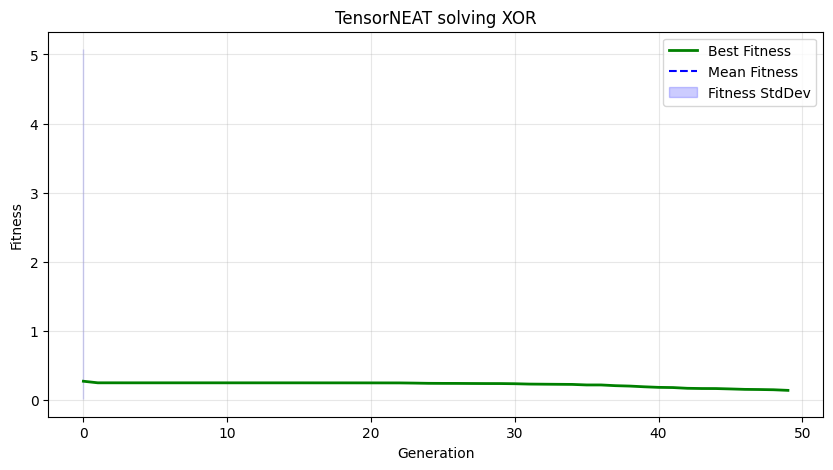

In [9]:
run = result.runs[0]
generations = jax.numpy.arange(len(run.history))
best_fitness = jax.numpy.array([h["best_fitness"] for h in run.history])
mean_fitness = jax.numpy.array([h["mean_fitness"] for h in run.history])
std_fitness = jax.numpy.array([h.get("std_fitness", 0.0) for h in run.history])

plt.figure(figsize=(10, 5))
plt.plot(generations, best_fitness, label="Best Fitness", color="green", linewidth=2)
plt.plot(generations, mean_fitness, label="Mean Fitness", color="blue", linestyle="--")

# Plot a shaded region for the standard deviation (mean +/- std)
plt.fill_between(
    generations, 
    mean_fitness - std_fitness, 
    mean_fitness + std_fitness, 
    color="blue", 
    alpha=0.2, 
    label="Fitness StdDev"
)

plt.title("TensorNEAT solving XOR")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()
plt.grid(True, alpha=0.3)
import os
os.makedirs("results/showcase", exist_ok=True)
plt.savefig("results/showcase/04_tensorneat_xor.png")
print("Plot saved to results/showcase/04_tensorneat_xor.png")
# plt.show() # Uncomment to view interactively

## 3. Conclusion

Because TensorNEAT emits `"std_fitness"` in its history, you can seamlessly add `"std_fitness"` to the `target_metrics` list of your `benchmark.toml` files, and the dynamic analyzer will generate Boxplots and Log-Log scaling laws for the standard deviation of the TensorNEAT population without writing any parsing code!

This concludes the MalthusJAX Showcase. You've seen the `Composer`, Universal Adapters, and Dynamic Benchmarking all working in harmony!